In [1]:
from netCDF4 import Dataset
import numpy as np
import xarray as xr

fldLoc = '/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/'
earthRad = 6.371e6  # earth radius m
Omega = 7.292e-5 # earth agular velocity rad/sec

fileName = 'GLORYS12v1_dailyAvg_2017-12-31.nc'
bathymetry_fileName = 'bath_CG.nc'

gridFileName = fldLoc + 'glorysGrid_forCG.nc'
latVar = 'latitude'
lonVar = 'longitude'

ds_0 = xr.open_dataset(fldLoc + fileName)

latInDeg = np.array(ds_0[latVar].to_numpy())
lonInDeg = np.array(ds_0[lonVar].to_numpy())
zos = ds_0.zos.isel(time=0).to_numpy()

waterArea = np.array(~np.isnan(zos), dtype=float)

ds_1 = xr.open_dataset(fldLoc + bathymetry_fileName)
h = ds_1.deptho.to_numpy()

xlen = len(lonInDeg)
ylen = len(latInDeg)

dx = np.zeros((ylen, xlen), dtype=float)
dy = np.zeros((ylen, xlen), dtype=float)

lon = np.deg2rad(lonInDeg)
lat = np.deg2rad(latInDeg)

lon_2d, lat_2d = np.meshgrid(lonInDeg, latInDeg)
coriolis = 2 * Omega * np.sin(np.deg2rad(lat))

dlon = abs(lon[1] - lon[0])
dlat = abs(lat[1] - lat[0])

for i in range(ylen):
    R = earthRad * np.cos(lat[i])
    dx[i,:] = R*dlon
    dy[i,:] = earthRad * dlat

coords = {'latitude': latInDeg, 'longitude': lonInDeg}

xds = xr.Dataset(
    {
        'DXU': (['latitude', 'longitude'], dx, {'units': 'm', 'long_name': 'east west cell width'}),
        'DYU': (['latitude', 'longitude'], dy, {'units': 'm', 'long_name': 'north south cell width'}),
        'UAREA': (['latitude', 'longitude'], dx*dy, {'units': 'm^2', 'long_name': 'cell area'}),
        'ULAT': (['latitude', 'longitude'], lat_2d, {'units': 'deg N', 'long_name': 'latitude'}),
        'ULONG': (['latitude', 'longitude'], lon_2d, {'units': 'deg E', 'long_name': 'longitude'}),
        'KMU': (['latitude', 'longitude'], waterArea, {'units': 'sec^-1', 'long_name': 'water area 1 for water and 0 for land'}),
        'FCORU': (['latitude', 'longitude'], lon_2d, {'units': 'sec^-1', 'long_name': 'coriolis parameter'}),
        'HU': (['latitude', 'longitude'], h, {'units': 'm', 'long_name': 'ocean depth'}),
    },
    coords=coords
)

xds.to_netcdf(gridFileName)

xds.close()




In [2]:
ds_0

<xarray.Dataset>
Dimensions:    (time: 1, latitude: 385, longitude: 2245, depth: 28)
Coordinates:
  * latitude   (latitude) float32 -16.0 -15.92 -15.83 ... 15.83 15.92 16.0
  * depth      (depth) float32 0.494 1.541 2.646 3.819 ... 186.1 222.5 266.0
  * time       (time) datetime64[ns] 2017-12-31T12:00:00
  * longitude  (longitude) float32 109.0 109.1 109.2 109.2 ... 295.8 295.9 296.0
Data variables:
    mlotst     (time, latitude, longitude) float32 ...
    zos        (time, latitude, longitude) float32 ...
    bottomT    (time, latitude, longitude) float32 ...
    sithick    (time, latitude, longitude) float32 ...
    siconc     (time, latitude, longitude) float32 ...
    usi        (time, latitude, longitude) float32 ...
    vsi        (time, latitude, longitude) float32 ...
    thetao     (time, depth, latitude, longitude) float32 ...
    so         (time, depth, latitude, longitude) float32 ...
    uo         (time, depth, latitude, longitude) float32 ...
    vo         (time, depth, latitude, longitude) float32 ...
Attributes: (12/24)
    title:              daily mean fields from Global Ocean Physics Analysis ...
    easting:            longitude
    northing:           latitude
    history:            2019/03/25 00:22:56 MERCATOR OCEAN Netcdf creation
    source:             MERCATOR GLORYS12V1
    institution:        MERCATOR OCEAN
    ...                 ...
    latitude_min:       -80.0
    latitude_max:       90.0
    z_min:              0.494025
    z_max:              5727.917
    forecast_range:     6-day_forecast
    forecast_type:      hindcast

In [3]:
ds_1

<xarray.Dataset>
Dimensions:     (depth: 50, latitude: 385, longitude: 2245)
Coordinates:
  * latitude    (latitude) float32 -16.0 -15.92 -15.83 ... 15.83 15.92 16.0
  * depth       (depth) float32 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * longitude   (longitude) float32 109.0 109.1 109.2 ... 295.8 295.9 296.0
Data variables:
    mask        (depth, latitude, longitude) int8 ...
    deptho      (latitude, longitude) float32 5.548e+03 5.536e+03 ... 2.459e+03
    deptho_lev  (latitude, longitude) float32 ...
Attributes: (12/13)
    title:                Bathymetry and mask for product GLOBAL_REANALYSIS_P...
    references:           http://marine.copernicus.eu
    credit:               E.U. Copernicus Marine Service Information (CMEMS)
    licence:              http://marine.copernicus.eu/services-portfolio/serv...
    contact:              servicedesk.cmems@mercator-ocean.eu
    producer:             CMEMS - Global Monitoring and Forecasting Centre
    ...                   ...
    Conventions:          CF-1.6
    area:                 GLOBAL
    source:               GLORYS12V1
    product:              GLOBAL_REANALYSIS_PHY_001_030
    dataset:              global-reanalysis-phy-001-030-statics
    product_user_manual:  http://marine.copernicus.eu/documents/PUM/CMEMS-GLO...

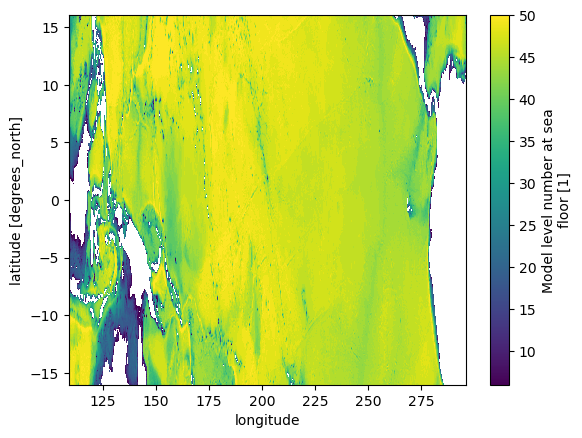

In [4]:
ds_1.deptho_lev.plot(x='longitude', y = 'latitude')